In [10]:
from pathlib import Path
from dataclasses import dataclass
from pprint import pprint
import pickle as pkl
from typing import Literal

import matplotlib.pylab as plt
from matplotlib.axes._axes import Axes
import numpy as np

from HexLatticePlot import HexCell, HexLattice, Coordinate, AxialCoordinate, DoubleWidthCoordinate, PlotConfig, ValidDirections

## Generate Simons HexLattice

In [11]:
def convert_axial_to_smdfr(axial_coord: AxialCoordinate) -> np.ndarray:
    A = np.array([[1, 1], [0, -1]])
    x = np.array([[axial_coord.x], [axial_coord.z]])
    smdfr_coord = A @ x
    return smdfr_coord

In [12]:
def coord_is_valid(coord: Coordinate) -> bool:
    """
    判断坐标是否在扇形区域内。
    要求：半径小于等于15，且角度在0到60度之间（以x轴正方向为0度）。
    """
    x, y = coord.cartesian.x, coord.cartesian.y
    r2 = x ** 2 + y ** 2
    if r2 > 15 ** 2:
        return False
    theta = np.arctan2(y, x)  # 弧度
    if 0 <= theta <= (np.pi / 3)*1.001:
        return True
    return False

In [13]:
smdfr: list[Coordinate] = list()
wait_list = list()
wait_list.append(Coordinate(AxialCoordinate(0, 0)))
while wait_list:
    pop_coord: Coordinate = wait_list.pop()

    # 如果坐标在半径内加入smdfr
    if coord_is_valid(pop_coord) and (pop_coord not in smdfr):
        smdfr.append(pop_coord)
        
    # 将合法的坐标的邻居加入等待列表
    for coord in pop_coord.get_all_neighbour():
        if coord_is_valid(coord) and (coord not in smdfr):
            wait_list.append(coord)

In [14]:
print(len(smdfr))

153


In [15]:
hexcell_list: list[HexCell] = []
for coord in smdfr:
    converted = convert_axial_to_smdfr(coord.axial)
    coord_text = f'({converted[0][0]}, {converted[1][0]})'
    hexcell_list.append(HexCell(coord, text=coord_text))
hl = HexLattice(hexcell_list)

## Write data into HexCells

## Plot

In [16]:
pc = PlotConfig('smDFR coordinates in axial system')
pc.image_root_dir = Path('examples/plot')
pc.image_type = 'png'
pc.plot_style = 'bmh'
pc.hex_face_color = "#fdf3ee"

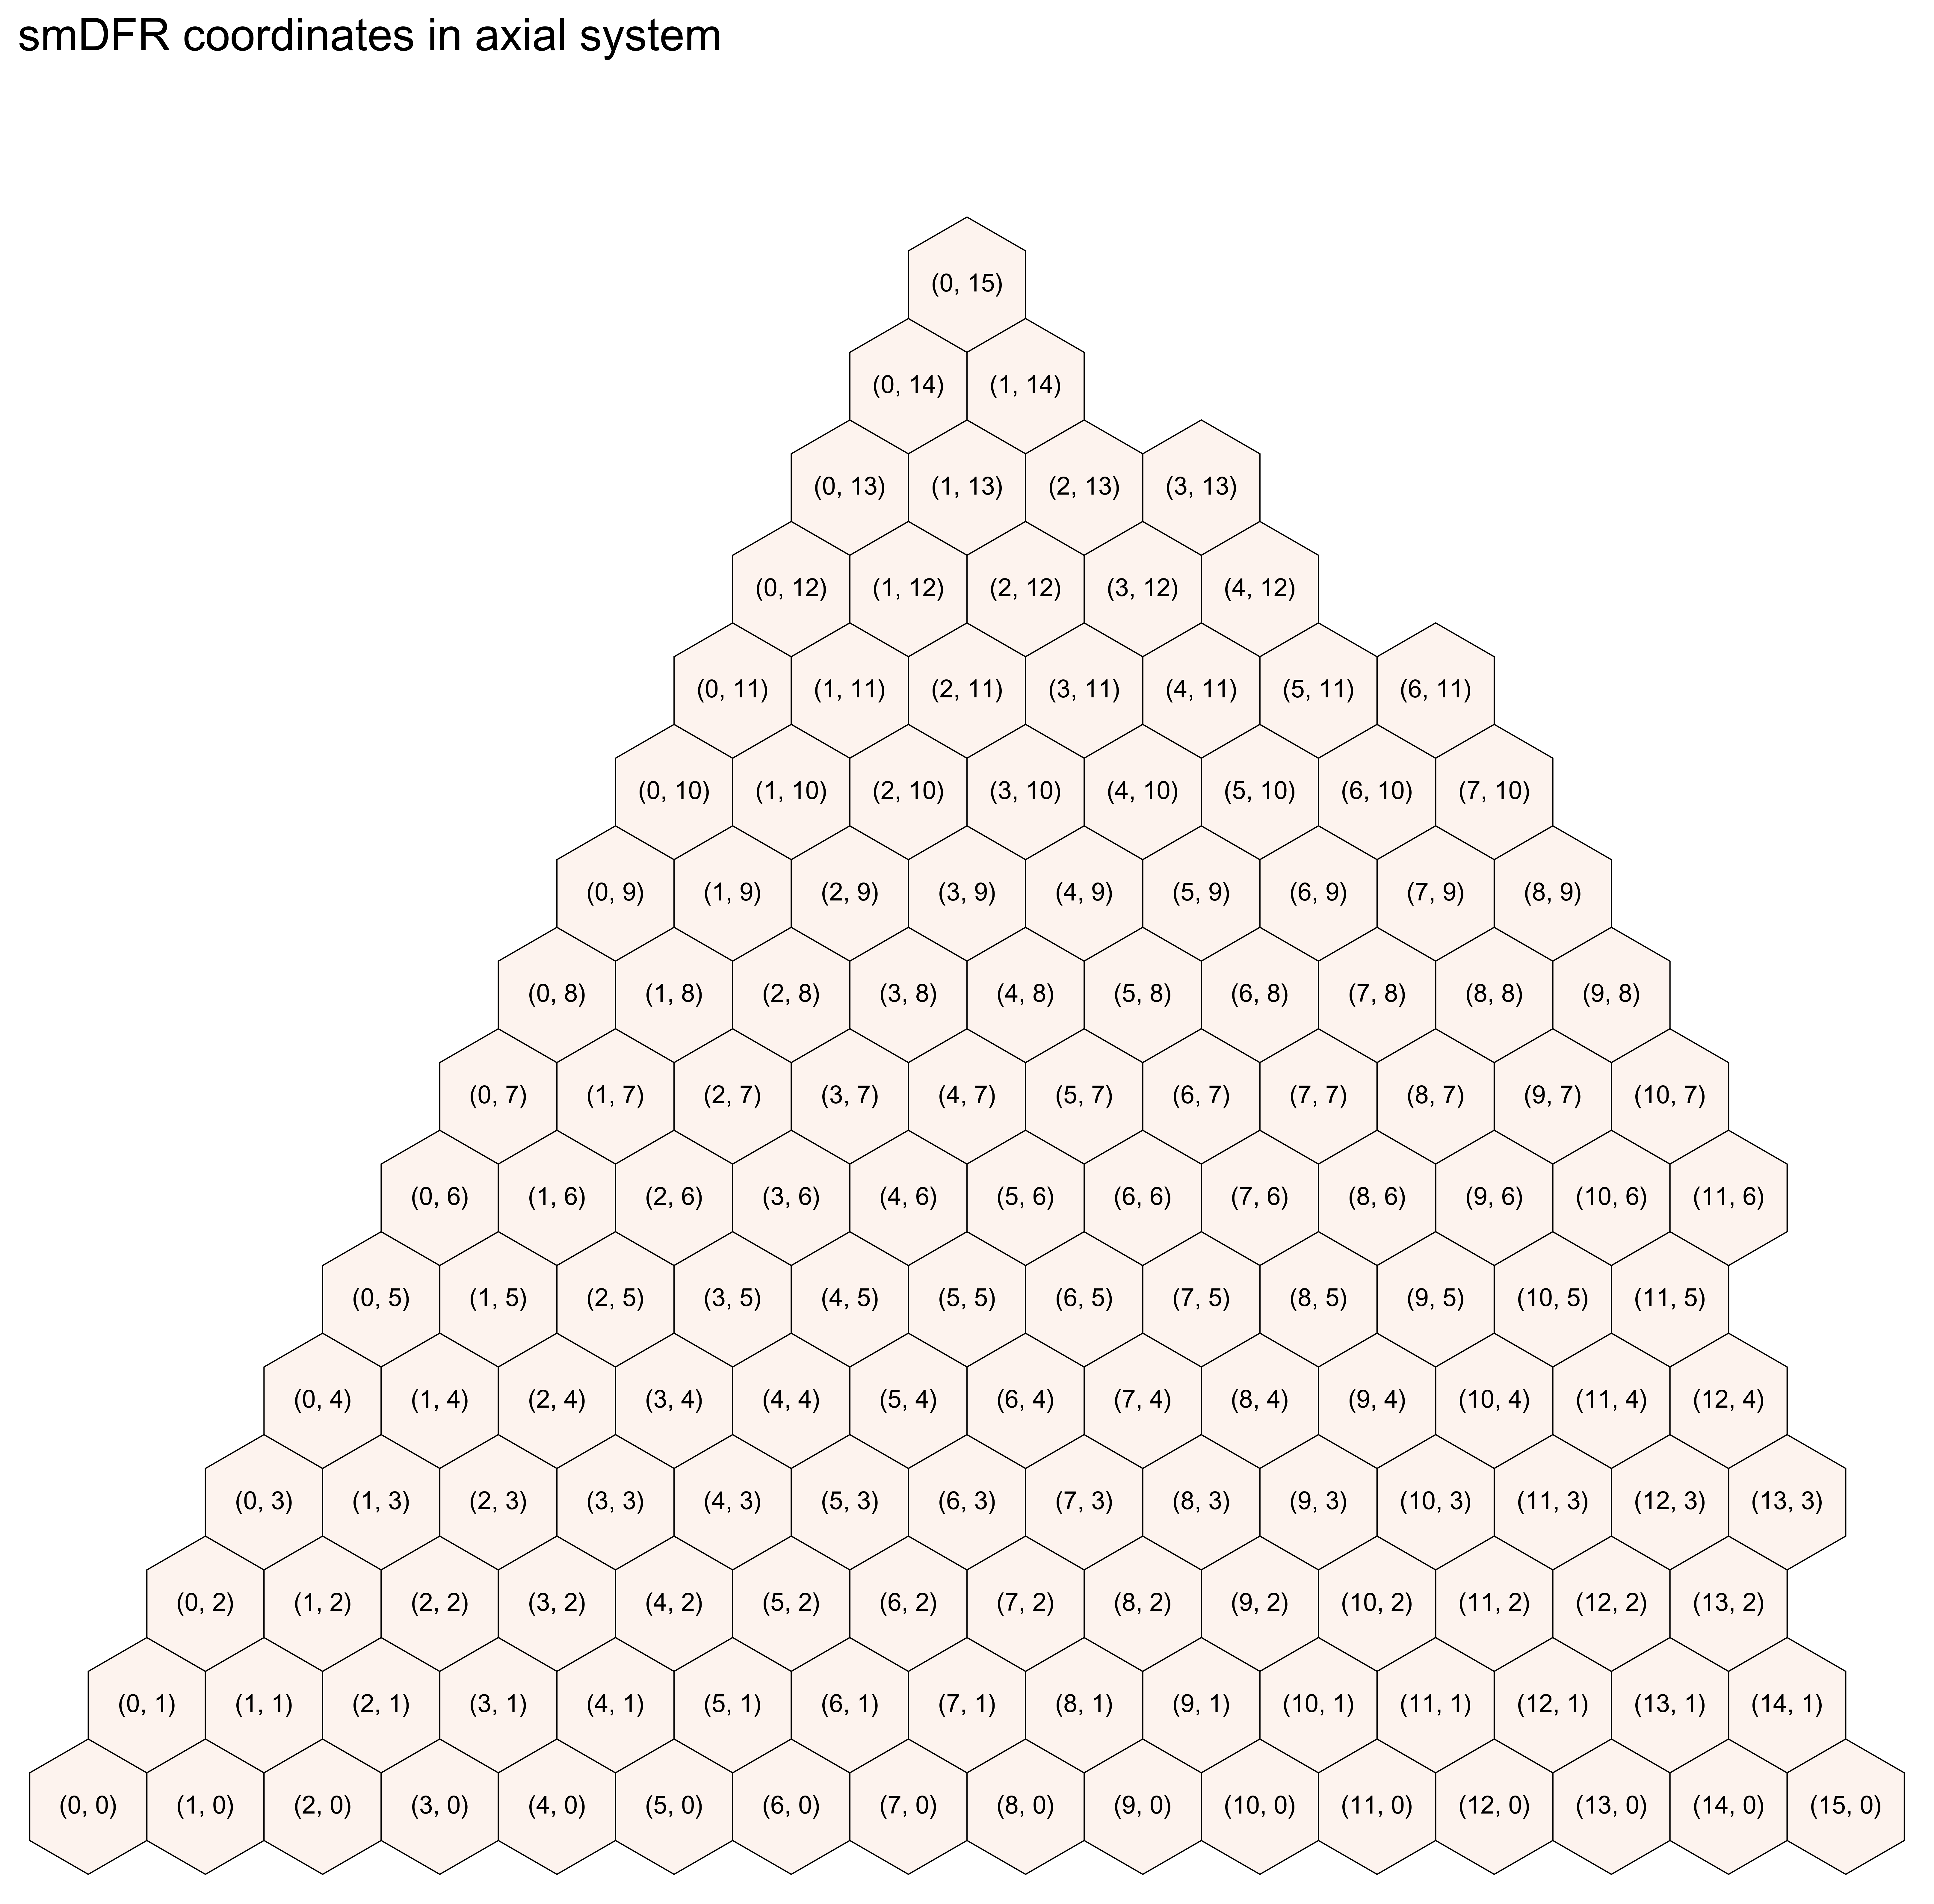

In [17]:
ax, _ = hl.plot(
    pc,
    shape="hex",
    text_mode="text",
    save=True,
    show=True,
    close=True,
)